Title: capacity_data_offshore.ipynb

Purpose: Transform the xml capacity data into some gridded format

Author: Onno Nennecke on 10.02.2025 Modified: 15.02.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Seelage': int(einheit.find('Seelage').text) if einheit.find('Seelage') is not None else np.nan,
            # 'ClusterNordsee': int(einheit.find('ClusterNordsee').text) if einheit.find('ClusterNordsee') is not None else np.nan,
            # 'ClusterOstsee': int(einheit.find('ClusterOstsee').text) if einheit.find('ClusterOstsee') is not None else np.nan,
            'Wassertiefe': float(einheit.find('Wassertiefe').text) if einheit.find('Wassertiefe') is not None else np.nan,
            'Kuestenentfernung': float(einheit.find('Kuestenentfernung').text) if einheit.find('Kuestenentfernung') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
print(df)

      EinheitMastrNummer  Bruttoleistung  Nettonennleistung   Lage  \
0        SEE940146675093          3000.0             3000.0  888.0   
1        SEE973767078653          3000.0             3000.0  888.0   
2        SEE914108319653          3000.0             3000.0  888.0   
3        SEE982417853618          3000.0             3000.0  888.0   
4        SEE913741454097          2400.0             2400.0  888.0   
...                  ...             ...                ...    ...   
38070    SEE938428285726          3500.0             3500.0  888.0   
38071    SEE987122644452          3500.0             3500.0  888.0   
38072    SEE924447498896          3500.0             3500.0  888.0   
38073    SEE938294352034          4200.0             4200.0  888.0   
38074    SEE987180399516          7200.0             7200.0  888.0   

                  NameWindpark  Nabenhoehe  Rotordurchmesser  Seelage  \
0          Windpark Kreuzstein      149.08            115.71      NaN   
1            

In [4]:
# Drop closed units
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb
# df_1[df_1['Lage'].isna()]

# Add some missing values
df_1.loc[df_1['Lage'].isna(), 'Lage'] = 888


In [5]:
print(df_1[df_1['Lage'] == 889]['Nabenhoehe'].mean()) # Offshore
print(df_1[df_1['Lage'] != 889]['Nabenhoehe'].mean()) # Onshore
print(df_1['Nabenhoehe'].mean())
print(df_1[df_1['Lage'] == 889]['Nabenhoehe'].describe()) # Offshore
print(df_1[df_1['Lage'] != 889]['Nabenhoehe'].describe()) # Onshore


96.10388198757764
98.61327488119018
98.48145151396501
count    1610.000000
mean       96.103882
std        10.063147
min        67.000000
25%        90.000000
50%        92.990000
75%       104.500000
max       126.500000
Name: Nabenhoehe, dtype: float64
count    29038.000000
mean        98.613275
std         35.038866
min          1.000000
25%         70.000000
50%         98.350000
75%        135.000000
max        173.480000
Name: Nabenhoehe, dtype: float64


In [6]:
df_1['Lage'] = df_1['Lage'].replace({889: 'Offshore', 888: 'Onshore'})
# set(df_1['Lage'])

In [7]:
def weighted_mean(df, value_column, weight_column):
    return np.average(df[value_column], weights=df[weight_column])

df_2 = df_1.dropna(subset=['Nabenhoehe'])

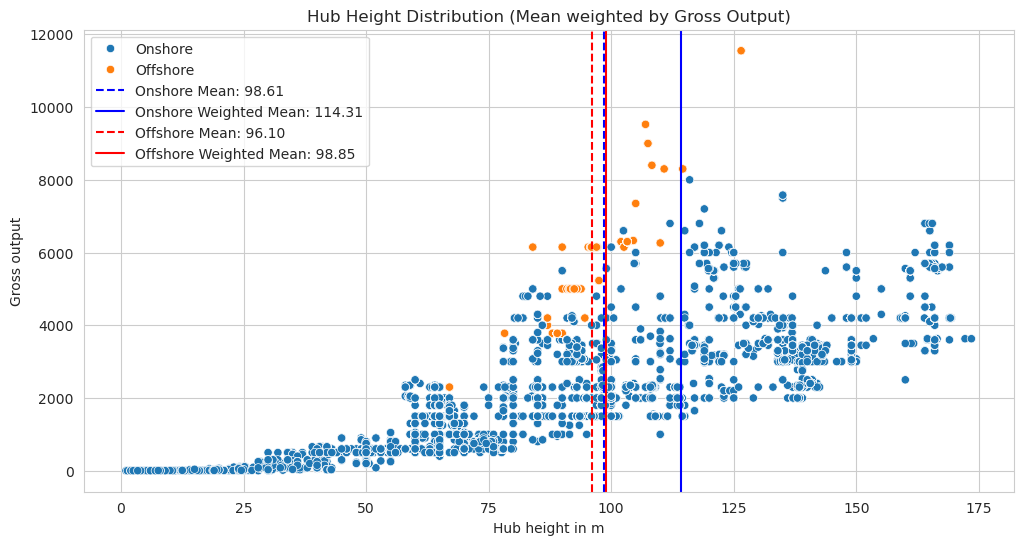

In [8]:
# Plot the height distribution coloured by the Lage
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_2, x='Nabenhoehe', y='Bruttoleistung', hue='Lage')
mean_onshore = df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean()
mean_offshore = df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean()
weighted_mean_onshore = weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung')
weighted_mean_offshore = weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung')

plt.axvline(mean_onshore, color='blue', linestyle='--', label=f'Onshore Mean: {mean_onshore:.2f}')
plt.axvline(weighted_mean_onshore, color='blue', linestyle='-', label=f'Onshore Weighted Mean: {weighted_mean_onshore:.2f}')
plt.axvline(mean_offshore, color='red', linestyle='--', label=f'Offshore Mean: {mean_offshore:.2f}')
plt.axvline(weighted_mean_offshore, color='red', linestyle='-', label=f'Offshore Weighted Mean: {weighted_mean_offshore:.2f}')
plt.xlabel('Hub height in m')
plt.ylabel('Gross output')
plt.legend()
plt.title('Hub Height Distribution (Mean weighted by Gross Output)')
plt.show()


In [26]:
print('Onshore: \n', df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].describe())
print(weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung'))
print('Onshore: \n', df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].describe())
print(weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung'))


Onshore: 
 count    29038.000000
mean        98.613275
std         35.038866
min          1.000000
25%         70.000000
50%         98.350000
75%        135.000000
max        173.480000
Name: Nabenhoehe, dtype: float64
114.31232198057913
Onshore: 
 count    1610.000000
mean       96.103882
std        10.063147
min        67.000000
25%        90.000000
50%        92.990000
75%       104.500000
max       126.500000
Name: Nabenhoehe, dtype: float64
98.84774531314085


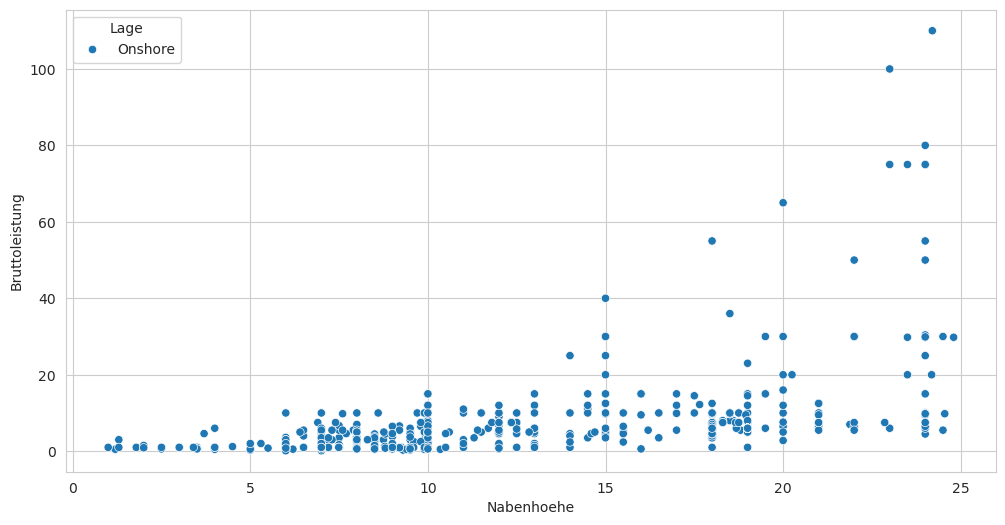

In [9]:
# Just out of curiosity plot the low power wind installations

# df_1['Nabenhoehe' < 25]['Bruttoleistung'].describe()
df_3 = df_1[df_1['Nabenhoehe'] < 25].copy()
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_3, x='Nabenhoehe', y='Bruttoleistung', hue='Lage')
# sns.scatterplot(data=df_1, x='Lage', y='Nabenhoehe')

plt.show()

In [10]:
# Open all height datasets

grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height.nc')
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height.nc')
grid_offshore_weighted = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
grid_onshore_weighted = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
#rename data variable
grid_offshore_weighted = grid_offshore_weighted.rename_vars({'wind_off_hub_height': 'wind_off_hub_height_weighted'})
grid_onshore_weighted = grid_onshore_weighted.rename_vars({'wind_on_hub_height': 'wind_on_hub_height_weighted'})

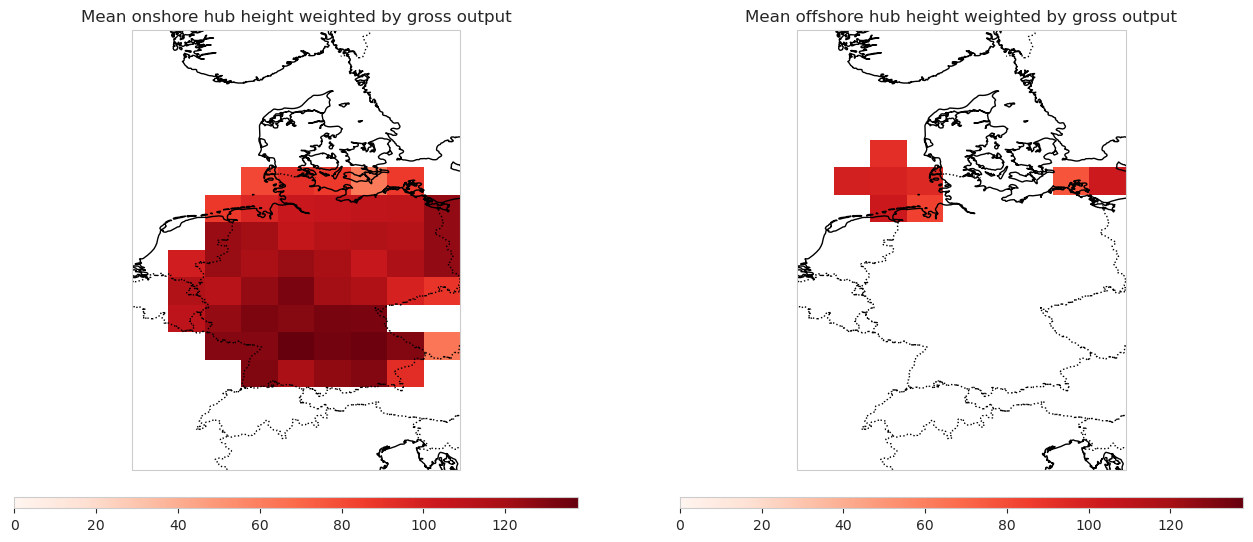

In [11]:
lon_edges = grid_offshore.lon.values - (grid_offshore.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_offshore.lat.values - (grid_offshore.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

xxx1 = grid_onshore_weighted['wind_on_hub_height_weighted']
xxx2 = grid_offshore_weighted['wind_off_hub_height_weighted']

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max())

# Plot the data with common colorbar range
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Mean onshore hub height weighted by gross output')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Mean offshore hub height weighted by gross output')



plt.tight_layout()
plt.show()

In [24]:
xxx1 = grid_onshore_weighted['wind_on_hub_height_weighted']
xxx2 = grid_offshore_weighted['wind_off_hub_height_weighted']

print('Onshore: \n', pd.Series(xxx1.values.flatten()).describe())
print('Offshore: \n', pd.Series(xxx2.values.flatten()).describe())

Onshore: 
 count     53.000000
mean     113.711855
std       17.823362
min       62.262376
25%      106.005103
50%      117.700187
75%      126.035563
max      137.752996
dtype: float64
Offshore: 
 count      8.000000
mean      93.946749
std        9.355829
min       76.700599
25%       90.121415
50%       96.573745
75%      100.369895
max      103.336626
dtype: float64


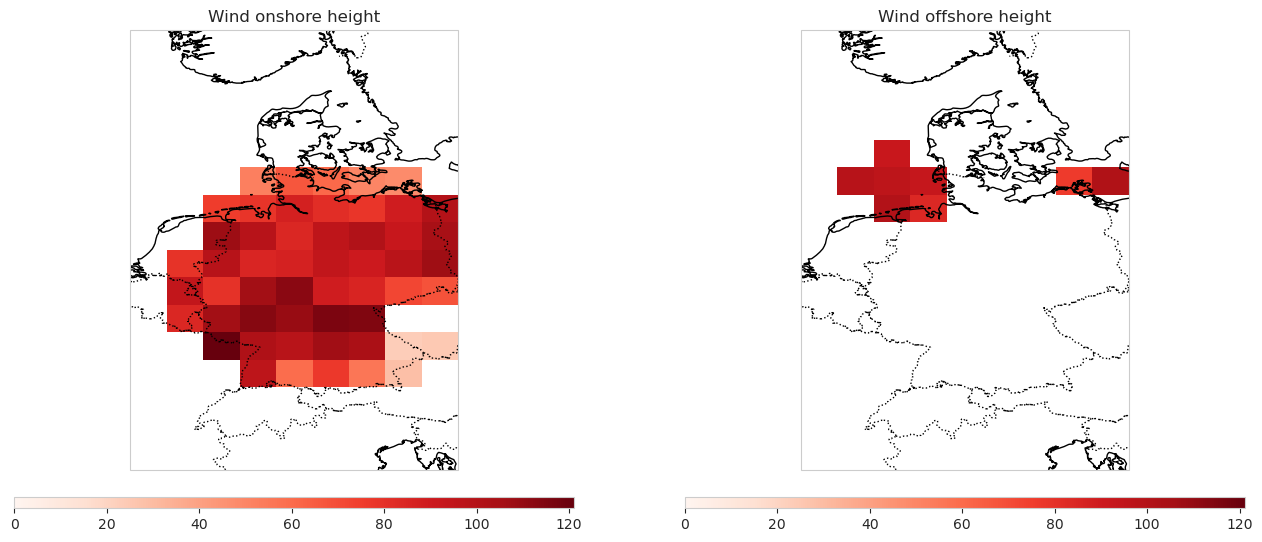

In [12]:
# Not weighted
lon_edges = grid_offshore.lon.values - (grid_offshore.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_offshore.lat.values - (grid_offshore.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

xxx1 = grid_onshore['wind_on_hub_height']
xxx2 = grid_offshore['wind_off_hub_height']

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max())

# Plot the data with common colorbar range
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Wind onshore height')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Wind offshore height')



plt.tight_layout()
plt.show()

In [13]:
# Load power data
grid_offshore_power = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_power.nc')
grid_onshore_power = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_power.nc')

In [14]:
# Combine the offshore data
grid_offshore_combined = xr.merge([grid_offshore, grid_offshore_weighted, grid_offshore_power])

# Combine the onshore data
grid_onshore_combined = xr.merge([grid_onshore, grid_onshore_weighted, grid_onshore_power])

In [15]:
print('Offshore:')
print('Gridded, not weighted: ', grid_offshore_combined['wind_off_hub_height'].mean().values)
print('Gridded, Weighted: ', grid_offshore_combined['wind_off_hub_height_weighted'].mean().values)
print('Original, not Weighted: ', df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean())
print('Original, Weighted: ', weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung'))

print('Onshore:')
print('Gridded, not weighted: ', grid_onshore_combined['wind_on_hub_height'].mean().values)
print('Gridded, Weighted: ', grid_onshore_combined['wind_on_hub_height_weighted'].mean().values)
print('Original, not Weighted: ', df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean())
print('Original, Weighted: ', weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung'))

Offshore:
Gridded, not weighted:  92.75319279891357
Gridded, Weighted:  93.94674949553115
Original, not Weighted:  96.10388198757764
Original, Weighted:  98.84774531314085
Onshore:
Gridded, not weighted:  85.66859123135976
Gridded, Weighted:  113.71185462978931
Original, not Weighted:  98.61327488119015
Original, Weighted:  114.31232198057913


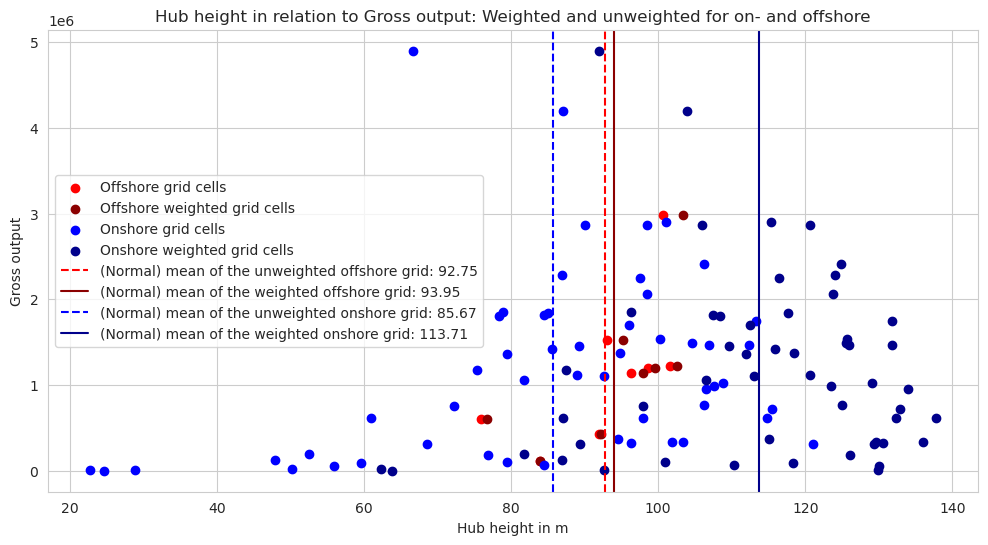

In [16]:
# Plot all data in one scatterplot (height against power) on and offshore labeled by colour
plt.figure(figsize=(12, 6))
plt.scatter(grid_offshore_combined['wind_off_hub_height'], grid_offshore_combined['wind_off_cap'], label='Offshore grid cells', color='red')
plt.scatter(grid_offshore_combined['wind_off_hub_height_weighted'], grid_offshore_combined['wind_off_cap'], label='Offshore weighted grid cells', color='darkred')

plt.scatter(grid_onshore_combined['wind_on_hub_height'], grid_onshore_combined['wind_on_cap'], label='Onshore grid cells', color='blue')
plt.scatter(grid_onshore_combined['wind_on_hub_height_weighted'], grid_onshore_combined['wind_on_cap'], label='Onshore weighted grid cells', color='darkblue')
mean_onshore = grid_onshore_combined['wind_on_hub_height'].mean().values # df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean()
mean_offshore = grid_offshore_combined['wind_off_hub_height'].mean().values # df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean()
weighted_mean_onshore = grid_onshore_combined['wind_on_hub_height_weighted'].mean().values # weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung')
weighted_mean_offshore = grid_offshore_combined['wind_off_hub_height_weighted'].mean().values # weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung')

# plt.axvline(mean_offshore, color='red', linestyle='--', label=f'Offshore Mean: {mean_offshore:.2f}')
# plt.axvline(weighted_mean_offshore, color='darkred', linestyle='-', label=f'Offshore Weighted Mean: {weighted_mean_offshore:.2f}')
# plt.axvline(mean_onshore, color='blue', linestyle='--', label=f'Onshore Mean: {mean_onshore:.2f}')
# plt.axvline(weighted_mean_onshore, color='darkblue', linestyle='-', label=f'Onshore Weighted Mean: {weighted_mean_onshore:.2f}')

plt.axvline(mean_offshore, color='red', linestyle='--', label=f'(Normal) mean of the unweighted offshore grid: {mean_offshore:.2f}')
plt.axvline(weighted_mean_offshore, color='darkred', linestyle='-', label=f'(Normal) mean of the weighted offshore grid: {weighted_mean_offshore:.2f}')
plt.axvline(mean_onshore, color='blue', linestyle='--', label=f'(Normal) mean of the unweighted onshore grid: {mean_onshore:.2f}')
plt.axvline(weighted_mean_onshore, color='darkblue', linestyle='-', label=f'(Normal) mean of the weighted onshore grid: {weighted_mean_onshore:.2f}')

plt.xlabel('Hub height in m')
plt.ylabel('Gross output')
plt.legend()
plt.title('Hub height in relation to Gross output: Weighted and unweighted for on- and offshore')
plt.show()